# E7 — Why Serving Is Memory-Bound: the KV Cache

> **Enrichment — not examinable.** The official unit content is in `examples/`. This lesson exists to connect what you just learned to how the field works in 2026.

## 📚 Learning Objectives

By completing this notebook, you will:
- Write an autoregressive decode loop **twice** — once recomputing everything, once keeping a key/value cache — and prove the two produce **bit-identical** output
- Measure the two cost curves and say, from your own timings, which response time grows with the **square** of its length and which does not
- Show that after caching, the remaining per-step cost tracks **bytes moved**, not arithmetic — the definition of *memory-bound*
- Compute, from **real published model configurations**, how many bytes of KV cache one token costs and how many concurrent requests fit in a fixed memory budget
- Measure how much of a reserved cache is actually used under fixed-length allocation versus paged blocks

## 🔗 Where this fits

**Builds on:** Unit 2, lesson 06 `examples/06_batch_vs_realtime_inference.ipynb` — that lesson measured a **678× difference in items per second** between one-row-at-a-time serving and 1,000-row batches, and opened by citing the vLLM paper's *2–4× throughput at the same latency*. It told you the batch size is the lever. This notebook shows you **what stops you from making the batch bigger**: the key/value cache, which is memory, not compute.

**Also builds on:** Unit 2, lesson 04 `examples/04_saving_loading_models_pickle_onnx.ipynb`, which measured file size and load time for one artifact. The cache below is the *other* memory cost of serving — the one that does not exist until a user shows up, and then grows with every token they generate.

**Used later in:** Unit 3 (cloud deployment) and Unit 4 (containers and orchestration), where "how many replicas do I need" is decided by exactly the arithmetic in Part 4, and Unit 5, where the memory ceiling is what your autoscaler is really reacting to.

## 🌍 Why this matters: the paper that made serving a memory problem

In September 2023 Kwon, Li, Zhuang, Sheng, Zheng, Yu, Gonzalez, Zhang and Stoica published *Efficient Memory Management for Large Language Model Serving with PagedAttention* ([arXiv:2309.06180](https://arxiv.org/abs/2309.06180)) — the paper behind **vLLM**. Read its opening claim carefully, because every word of it is about memory:

> "High throughput serving of large language models (LLMs) requires batching sufficiently many requests at a time. However, existing systems struggle because the key-value cache (KV cache) memory for each request is huge and grows and shrinks dynamically. When managed inefficiently, this memory can be significantly wasted by fragmentation and redundant duplication, limiting the batch size."

Their fix was to borrow **operating-system paging** for the cache, and the reported result was "near-zero waste in KV cache memory" and throughput "2–4× ... with the same level of latency compared to the state-of-the-art systems, such as FasterTransformer and Orca." No better model. No faster hardware. A better memory allocator.

**What goes wrong without this lesson.** A team benchmarks a served model with one request at a time, sees acceptable latency, sizes the cluster from that, and ships. Under real concurrency the machine runs out of memory long before it runs out of arithmetic, requests queue, and latency collapses — while the GPU utilization dashboard shows the accelerator is barely working. That dashboard is not lying: **the machine really is idle, waiting for memory.** You cannot fix that by buying more FLOPs.

**The claim this notebook will make you prove.** Autoregressive generation is not one big matrix multiply. It is *n* tiny ones, each of which must re-read a data structure that grows every step. Cache it and you delete most of the arithmetic; what is left is a memory-bandwidth problem, and every serving technique you will meet in 2026 — paging, prefix reuse, quantized caches, grouped-query and latent attention, speculative decoding — is a different way of moving fewer bytes.

## 📥 Inputs & 📤 Outputs

**Inputs:** no dataset and no downloads. Part 1–3 use a **toy attention layer** whose weights are drawn from a seeded normal distribution — this is the one place in this diploma where `np.random` is correct, because the *shape of the cost curve* is the lesson and the numbers in the weights are irrelevant to it (the pack that commissioned this lesson says so explicitly). Part 4 uses **five real, published model configurations** read from their `config.json` on the Hugging Face Hub and copied into this notebook as literals, so nothing is fetched at run time. Part 5 uses the **real README files of this repository** as a stand-in length distribution for concurrent requests.

**Outputs:** a bit-identical-output check between the two decode loops, two timing curves with a fitted growth exponent, the cached loop's achieved GFLOP/s and GB/s against this machine's measured compute and memory rates, a KV-cache size table for five real models, a concurrency calculation for a fixed memory budget, and measured cache utilization under fixed-length versus paged allocation.

**Runtime:** about 5 seconds on a CPU. Nothing here needs a GPU, and nothing here touches the network.

## Part 1: One Decode Loop, Written Twice

A transformer generating text does the same thing at every step: take the token it just produced, turn it into a query, compare that query against the keys of **every token so far**, and mix the corresponding values.

The keys and values of the earlier tokens **do not change**. Token 5's key is the same at step 6 as it was at step 500. So there are two ways to write the loop:

| | what it does at step *t* | work per step |
|---|---|---|
| **No cache** | recompute K and V for all *t* tokens from scratch | grows with *t* |
| **KV cache** | compute K and V for the **one** new token, append to a stored array | constant projection + a read of *t* rows |

That is the whole idea. It is not an optimization you enable with a flag — it is the reason `use_cache: true` appears in every config file you will read in Part 4. Below, both versions are written out in full, they share the same weights, and we will require them to agree **exactly**, not approximately: a cache that changes the output is a bug, not a trade-off.

In [1]:
# WHAT: build one toy attention layer and write the decode loop twice — without a KV cache
#       and with one. Same weights, same maths, different bookkeeping.
# WHY:  the cache is easy to describe and easy to get wrong. Writing both loops in full
#       is the only way to see that the cached version is not an approximation.
import time
import numpy as np
import pandas as pd

DT = np.float32                 # serving runs in low precision; float32 is the honest floor for NumPy
rng = np.random.default_rng(0)  # seeded: the WEIGHTS are irrelevant here, the cost curve is the lesson

N_HEADS, HEAD_DIM = 8, 64
D_MODEL = N_HEADS * HEAD_DIM    # 512 — a toy width, roughly 1/8 of a 7B model's hidden size
PROMPT_LEN = 32                 # the "prompt" already in context before generation starts
N_NEW = 1536                    # how many tokens we generate in the head-to-head comparison

# Four projection matrices: query, key, value, output. Scaled so activations stay O(1).
Wq, Wk, Wv, Wo = (rng.normal(0, 1 / np.sqrt(D_MODEL), (D_MODEL, D_MODEL)).astype(DT)
                  for _ in range(4))
prompt = rng.normal(0, 1, (PROMPT_LEN, D_MODEL)).astype(DT)
SCALE = DT(1.0 / np.sqrt(HEAD_DIM))


def to_heads(x):
    """(tokens, D_MODEL) -> (heads, tokens, HEAD_DIM), contiguous so BLAS can use it."""
    return np.ascontiguousarray(x.reshape(x.shape[0], N_HEADS, HEAD_DIM).transpose(1, 0, 2))


def decode_step(x_last, K, V):
    """One generation step: attend the newest token's query over ALL keys/values, then project out."""
    q = (x_last @ Wq).reshape(N_HEADS, HEAD_DIM, 1)     # (H, hd, 1) — a single query per head
    scores = (K @ q)[:, :, 0] * SCALE                   # (H, t) — one score per cached position
    scores -= scores.max(-1, keepdims=True)             # numerically safe softmax
    weights = np.exp(scores)
    weights /= weights.sum(-1, keepdims=True)
    ctx = (weights[:, None, :] @ V)[:, 0, :].reshape(1, D_MODEL)   # (1, D) — the mixed values
    return x_last + np.tanh(ctx @ Wo)                   # residual connection, as in a real block


def decode_no_cache(n_new, capacity):
    """Version A: at every step, rebuild K and V for the ENTIRE history."""
    X = np.zeros((capacity, D_MODEL), DT)
    X[:PROMPT_LEN] = prompt
    t = PROMPT_LEN
    per_step = np.empty(n_new)
    for i in range(n_new):
        t0 = time.perf_counter()
        history = X[:t]
        K = to_heads(history @ Wk)          # <- the wasted work: t x D @ D x D, every single step
        V = to_heads(history @ Wv)
        X[t] = decode_step(X[t - 1:t], K, V)[0]
        t += 1
        per_step[i] = time.perf_counter() - t0
    return X[:t].copy(), per_step


def decode_with_cache(n_new, capacity):
    """Version B: keep K and V in a pre-allocated buffer and append one row per step."""
    X = np.zeros((capacity, D_MODEL), DT)
    X[:PROMPT_LEN] = prompt
    # The cache itself. Pre-allocated to the maximum length we will ever need —
    # remember this line: it is exactly the over-reservation Part 5 measures.
    K_cache = np.zeros((N_HEADS, capacity, HEAD_DIM), DT)
    V_cache = np.zeros((N_HEADS, capacity, HEAD_DIM), DT)
    K_cache[:, :PROMPT_LEN] = to_heads(prompt @ Wk)     # prefill: the prompt is processed once
    V_cache[:, :PROMPT_LEN] = to_heads(prompt @ Wv)
    t = PROMPT_LEN
    per_step = np.empty(n_new)
    for i in range(n_new):
        t0 = time.perf_counter()
        X[t] = decode_step(X[t - 1:t], K_cache[:, :t], V_cache[:, :t])[0]
        K_cache[:, t] = (X[t:t + 1] @ Wk).reshape(N_HEADS, HEAD_DIM)   # one new row, not t rows
        V_cache[:, t] = (X[t:t + 1] @ Wv).reshape(N_HEADS, HEAD_DIM)
        t += 1
        per_step[i] = time.perf_counter() - t0
    return X[:t].copy(), per_step


print(f"Toy decoder: {N_HEADS} heads x {HEAD_DIM} dims = {D_MODEL}-wide, "
      f"{PROMPT_LEN}-token prompt, generating {N_NEW} tokens")
print(f"Parameters in the four projections: {4 * D_MODEL * D_MODEL:,}")

Toy decoder: 8 heads x 64 dims = 512-wide, 32-token prompt, generating 1536 tokens
Parameters in the four projections: 1,048,576


## Part 2: The Comparative Experiment

**Baseline:** generate 1,024 tokens with `decode_no_cache`.
**Change exactly one thing:** keep the keys and values instead of rebuilding them — `decode_with_cache`.
**Re-run, and compare** the output arrays first, then the timings.

The output check comes first on purpose. If the two arrays differ, every timing below is meaningless.

In [2]:
# WHAT: run both loops on the same prompt and the same weights, then compare outputs and timings.
# WHY:  this is the whole experiment. One variable changes — whether K and V are kept — and we
#       demand that the generated sequence does not change at all before we look at the clock.
capacity = PROMPT_LEN + N_NEW

t0 = time.perf_counter()
X_nocache, steps_nocache = decode_no_cache(N_NEW, capacity)
total_nocache = time.perf_counter() - t0

t0 = time.perf_counter()
X_cached, steps_cached = decode_with_cache(N_NEW, capacity)
total_cached = time.perf_counter() - t0

max_diff = float(np.abs(X_nocache - X_cached).max())
print("CORRECTNESS")
print(f"  largest absolute difference between the two generated sequences: {max_diff:g}")
print(f"  arrays bit-identical: {np.array_equal(X_nocache, X_cached)}")
print("  (If this were anything but 0, the cache would be changing the model's output.)\n")

def window(a, k=64):
    """Average per-step time over the first and last k steps, in microseconds."""
    return a[:k].mean() * 1e6, a[-k:].mean() * 1e6

first_nc, last_nc = window(steps_nocache)
first_c, last_c = window(steps_cached)

print("COST")
print(f"  no cache : total {total_nocache:7.3f} s | per step {first_nc:8.1f} us -> {last_nc:8.1f} us "
      f"({last_nc / first_nc:5.1f}x slower by the end)")
print(f"  KV cache : total {total_cached:7.3f} s | per step {first_c:8.1f} us -> {last_c:8.1f} us "
      f"({last_c / first_c:5.1f}x slower by the end)")
print(f"  end-to-end speedup from caching: {total_nocache / total_cached:.1f}x over {N_NEW} tokens")

CORRECTNESS
  largest absolute difference between the two generated sequences: 0
  arrays bit-identical: True
  (If this were anything but 0, the cache would be changing the model's output.)

COST
  no cache : total   1.159 s | per step     84.0 us ->   1506.6 us ( 17.9x slower by the end)
  KV cache : total   0.082 s | per step     23.0 us ->     84.6 us (  3.7x slower by the end)
  end-to-end speedup from caching: 14.1x over 1536 tokens


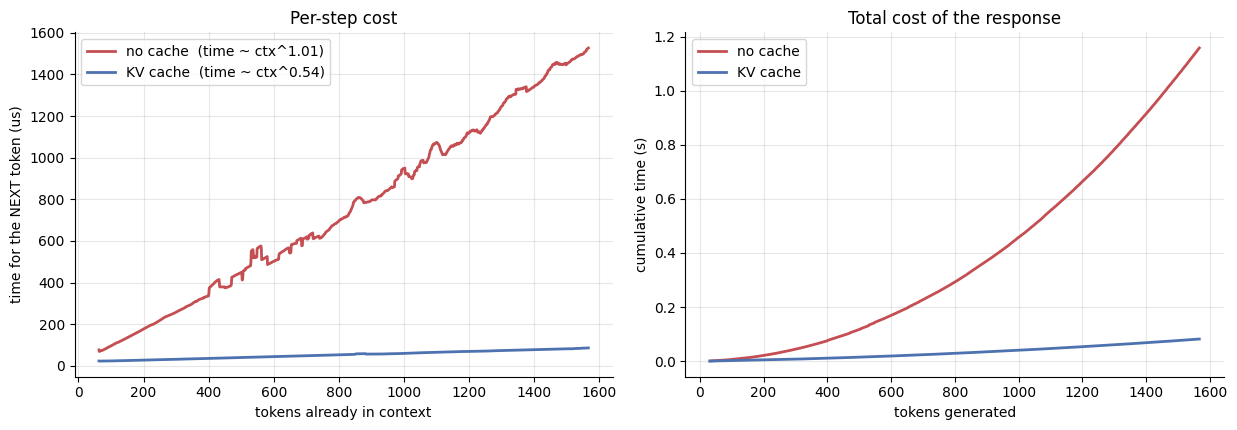

Fitted growth exponent p, where per-step time ~ context^p:
  no cache : p = 1.01   (p = 1 means the next token costs more the longer the answer already is)
  KV cache : p = 0.54   (p = 0 would mean every token costs the same)

A per-step cost proportional to context integrates to a PARABOLA in total time;
the cached curve is far shallower, so its total is much closer to a straight LINE.
Part 3 asks what the cached loop is still paying for, since it is not p = 0.


In [3]:
# WHAT: fit a power law  time ~ context^p  to each per-step curve, and plot both curves.
# WHY:  "faster" is not the lesson — the SHAPE is. The exponent p says whether the cost of the
#       next token depends on how much you have already written.
import matplotlib.pyplot as plt   # the notebook kernel renders inline; no window is opened

context = np.arange(PROMPT_LEN, PROMPT_LEN + N_NEW)   # tokens already in context at each step

def growth_exponent(per_step, ctx):
    """Slope of log(time) vs log(context) — 1.0 means linear in context, 0.0 means flat."""
    mask = ctx >= ctx[0] * 4          # ignore the first steps, where fixed overhead dominates
    return float(np.polyfit(np.log(ctx[mask]), np.log(per_step[mask]), 1)[0])

p_nocache = growth_exponent(steps_nocache, context)
p_cached = growth_exponent(steps_cached, context)

def smooth(a, w=32):
    return np.convolve(a, np.ones(w) / w, mode="valid")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))

axes[0].plot(context[31:], smooth(steps_nocache) * 1e6, color="#C44E52", lw=2,
             label=f"no cache  (time ~ ctx^{p_nocache:.2f})")
axes[0].plot(context[31:], smooth(steps_cached) * 1e6, color="#4C72B0", lw=2,
             label=f"KV cache  (time ~ ctx^{p_cached:.2f})")
axes[0].set_xlabel("tokens already in context")
axes[0].set_ylabel("time for the NEXT token (us)")
axes[0].set_title("Per-step cost")
axes[0].legend()

axes[1].plot(context, np.cumsum(steps_nocache), color="#C44E52", lw=2, label="no cache")
axes[1].plot(context, np.cumsum(steps_cached), color="#4C72B0", lw=2, label="KV cache")
axes[1].set_xlabel("tokens generated")
axes[1].set_ylabel("cumulative time (s)")
axes[1].set_title("Total cost of the response")
axes[1].legend()

for ax in axes:
    ax.grid(alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Fitted growth exponent p, where per-step time ~ context^p:")
print(f"  no cache : p = {p_nocache:.2f}   (p = 1 means the next token costs more the longer "
      f"the answer already is)")
print(f"  KV cache : p = {p_cached:.2f}   (p = 0 would mean every token costs the same)")
print(f"\nA per-step cost proportional to context integrates to a PARABOLA in total time;")
print(f"the cached curve is far shallower, so its total is much closer to a straight LINE.")
print(f"Part 3 asks what the cached loop is still paying for, since it is not p = 0.")

## Conclusion the printed numbers support

**First, correctness.** The largest absolute difference between the two generated sequences was **exactly 0** — the arrays are bit-identical. Nothing that follows is a quality trade-off; the cache is free.

**Without a cache, the cost of a token depends on how much you have already written.** The 1,536th token took **1506.6 µs** against **84.0 µs** for the first — **17.9× more** — and the fitted exponent was **p = 1.01**, i.e. per-step time is proportional to context length. A per-step cost that is linear in context integrates to a **quadratic** total, which is exactly the parabola in the right-hand panel. This is the sentence to carry into a capacity plan: without a cache, a 2,000-token answer does not cost twice a 1,000-token answer, it costs about four times as much.

**With a cache, the same 1,536 tokens took 0.082 s instead of 1.159 s — 14.1× less** — and the exponent fell to **p = 0.54**. The cumulative curve is close to a straight line.

**What these numbers do not support.** They do not show that caching makes per-token cost constant. p = 0.54 is not 0, and the last cached token still cost **3.7×** the first. Something in the cached loop still grows with context, and it is not the arithmetic — Part 3 measures what it is.

## Part 3: What Is Left Is Memory Traffic

The cache removed the recomputation. It did **not** make the per-step cost constant, and the second exponent above is not zero. Something still grows with context — and it is not arithmetic.

Count what one cached decode step actually does, at context length *t*, with *H* heads of width *d*:

- **arithmetic**: about `4·t·H·d` floating-point operations for the attention (one multiply-add per cached number, twice: once to score, once to mix), plus a fixed `8·D²` for the four projections
- **memory**: it must read the whole key cache and the whole value cache — `2·t·H·d` numbers — every step

So the ratio, the **arithmetic intensity**, is roughly `4 / (2 × bytes_per_number)` — **0.5 FLOPs per byte in float32**, and it does not improve as *t* grows. Every byte you load is used for half an operation and thrown away.

Compare that against what the machine can do. A large matrix multiply is the opposite case: each loaded byte feeds hundreds of operations. Below we measure both on **this** machine and put the decode loop where it belongs on that scale.

In [4]:
# WHAT: (a) measure this machine's peak matmul throughput and sequential read bandwidth;
#       (b) run the cached decoder out to a long context and measure what IT achieves.
# WHY:  "memory-bound" is not an opinion. It is the observation that a loop achieves a tiny
#       fraction of the machine's arithmetic while saturating a large fraction of its bandwidth.
N_LONG = 6144

def best_of(fn, repeats=5):
    """Fastest of several runs — the least noisy estimate of what the machine can do."""
    fn()                                               # warm-up: the first call pays setup costs
    best = float("inf")
    for _ in range(repeats):
        t0 = time.perf_counter()
        fn()
        best = min(best, time.perf_counter() - t0)
    return best

# (a) Machine capability, measured here rather than quoted from a spec sheet.
A = rng.normal(0, 1, (1500, 1500)).astype(DT)
B = rng.normal(0, 1, (1500, 1500)).astype(DT)
peak_flops = 2 * 1500 ** 3 / best_of(lambda: A @ B)    # 2 FLOPs (mul+add) per inner-product term

# For bandwidth we time a large matrix-VECTOR product, not a reduction: it reads every byte of
# the matrix and does exactly 2 FLOPs with each number — the same shape as a cached attention
# step, so it is the fair "memory-bound BLAS" reference rather than an optimistic peak.
M = rng.normal(0, 1, (8000, 8000)).astype(DT)          # 256 MB, far larger than any CPU cache
v = rng.normal(0, 1, 8000).astype(DT)
read_bw = M.nbytes / best_of(lambda: M @ v)

print("THIS MACHINE, MEASURED")
print(f"  matrix-matrix (compute-bound) : {peak_flops / 1e9:8.0f} GFLOP/s")
print(f"  matrix-vector (memory-bound)  : {read_bw / 1e9:8.0f} GB/s")
print(f"  ridge point                   : {peak_flops / read_bw:8.1f} FLOPs per byte "
      f"— a loop below this line is waiting on memory\n")

# (b) The cached decoder at long context.
t0 = time.perf_counter()
_, steps_long = decode_with_cache(N_LONG, PROMPT_LEN + N_LONG)
total_long = time.perf_counter() - t0

ctx_long = np.arange(PROMPT_LEN, PROMPT_LEN + N_LONG)
cache_bytes = 2 * ctx_long * D_MODEL * np.dtype(DT).itemsize     # K and V, both read every step
flops_step = 4 * ctx_long * D_MODEL + 8 * D_MODEL ** 2           # attention + the four projections

tail = slice(-512, None)                                          # measure at long context
achieved_bw = (cache_bytes[tail] / steps_long[tail]).mean()
achieved_flops = (flops_step[tail] / steps_long[tail]).mean()

print(f"CACHED DECODE at context ~{ctx_long[-1]:,} ({total_long:.2f} s for {N_LONG} tokens)")
print(f"  KV cache read per step : {cache_bytes[-1] / 1e6:8.2f} MB")
print(f"  achieved arithmetic    : {achieved_flops / 1e9:8.1f} GFLOP/s  "
      f"= {100 * achieved_flops / peak_flops:.1f}% of this machine's matmul peak")
print(f"  achieved cache read    : {achieved_bw / 1e9:8.1f} GB/s     "
      f"= {100 * achieved_bw / read_bw:.0f}% of this machine's memory-bound BLAS rate")
print(f"  intensity, attention   : {4 * ctx_long[-1] * D_MODEL / cache_bytes[-1]:8.2f} FLOPs/byte "
      f"(exactly 4 / (2 x 4 bytes), and independent of context length)")
print(f"  intensity, whole step  : {flops_step[-1] / cache_bytes[-1]:8.2f} FLOPs/byte "
      f"vs a ridge point of {peak_flops / read_bw:.1f} — a factor of "
      f"{peak_flops / read_bw / (flops_step[-1] / cache_bytes[-1]):.0f} below it")

THIS MACHINE, MEASURED
  matrix-matrix (compute-bound) :     1732 GFLOP/s
  matrix-vector (memory-bound)  :       70 GB/s
  ridge point                   :     24.7 FLOPs per byte — a loop below this line is waiting on memory



CACHED DECODE at context ~6,175 (1.40 s for 6144 tokens)
  KV cache read per step :    25.29 MB
  achieved arithmetic    :     32.2 GFLOP/s  = 1.9% of this machine's matmul peak
  achieved cache read    :     54.9 GB/s     = 78% of this machine's memory-bound BLAS rate
  intensity, attention   :     0.50 FLOPs/byte (exactly 4 / (2 x 4 bytes), and independent of context length)
  intensity, whole step  :     0.58 FLOPs/byte vs a ridge point of 24.7 — a factor of 42 below it


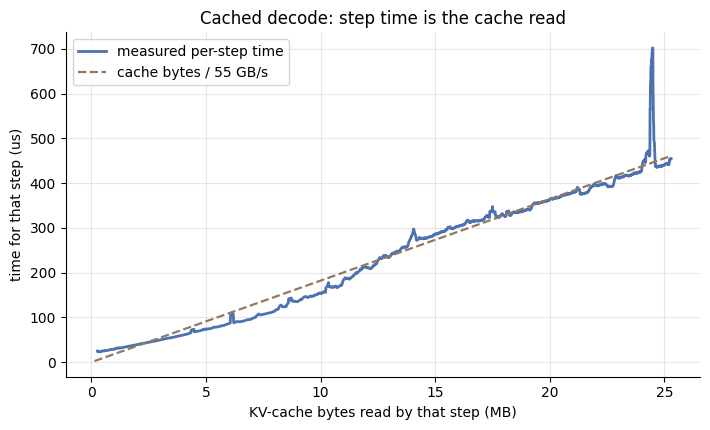

Correlation between per-step time and cache bytes read: r = 0.938 on the raw timings, r = 0.988 on the 32-step average that is plotted.
(Individual step timings are noisy on a shared laptop CPU; the average is the signal.)
The dashed line is not fitted to the timing curve — it is the cache size divided by the
bandwidth this loop achieved. Where the two lines sit on top of each other, the model is
not computing. It is reading.


In [5]:
# WHAT: plot per-step decode time against the number of KV-cache bytes it had to read.
# WHY:  if the relationship is a straight line through the origin, the step time IS the memory
#       read — that is what "memory-bound" means, drawn.
fig, ax = plt.subplots(figsize=(7.2, 4.4))
ax.plot(cache_bytes[31:] / 1e6, smooth(steps_long) * 1e6, color="#4C72B0", lw=2,
        label="measured per-step time")
ref = cache_bytes / achieved_bw
ax.plot(cache_bytes / 1e6, ref * 1e6, "--", color="#937860", lw=1.6,
        label=f"cache bytes / {achieved_bw / 1e9:.0f} GB/s")
ax.set_xlabel("KV-cache bytes read by that step (MB)")
ax.set_ylabel("time for that step (us)")
ax.set_title("Cached decode: step time is the cache read")
ax.legend()
ax.grid(alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

r_raw = np.corrcoef(cache_bytes, steps_long)[0, 1]
r_smooth = np.corrcoef(cache_bytes[31:], smooth(steps_long))[0, 1]
print(f"Correlation between per-step time and cache bytes read: r = {r_raw:.3f} on the raw "
      f"timings, r = {r_smooth:.3f} on the 32-step average that is plotted.")
print("(Individual step timings are noisy on a shared laptop CPU; the average is the signal.)")
print("The dashed line is not fitted to the timing curve — it is the cache size divided by the")
print("bandwidth this loop achieved. Where the two lines sit on top of each other, the model is")
print("not computing. It is reading.")

## 💬 Discuss

1. The cache made this loop **faster** while making it achieve a far **smaller** fraction of the machine's arithmetic peak. A colleague looks at a GPU utilization dashboard showing 8% and concludes the serving code is inefficient. Using the two numbers printed above, write the two-sentence reply that explains why raising that percentage is the wrong goal — and say what number you would put on the dashboard instead.
2. Halving the cache precision (float32 → float16) halves the bytes read per step but does not change the FLOP count. Predict, from the arithmetic-intensity argument, what that does to per-step latency — and then say what it costs you that a latency chart will never show.
3. Part 2 proved the two loops give bit-identical output, so caching is free correctness-wise. Name a serving feature you have already met in this unit that is **not** free in the same way, and say what you would have to measure to know whether it changed the model's answers.

## Part 4: How Big Is This Cache on a Real Model?

The toy above has one layer. Real models stack dozens, and **every layer keeps its own cache**. The size of one token's cache entry is fixed by four numbers you can read straight out of any model's `config.json`:

```
bytes per token = 2 (K and V) × layers × kv_heads × head_dim × bytes_per_number
```

The configurations below were read from each model's `config.json` on the Hugging Face Hub and are reproduced here as literals — this cell does not touch the network. You can check every row yourself against the model's page.

Notice `num_key_value_heads` in particular. Four of these five models have **8** key/value heads while having 32 or 64 *query* heads: that is **grouped-query attention**, and it exists for one reason — to make this table's second column smaller.

In [6]:
# WHAT: compute KV-cache size per token, and per full-context request, for five real models.
# WHY:  this arithmetic — not the parameter count — is what decides how many users fit on a box.
BYTES_PER_NUMBER = 2          # bf16/fp16, the standard serving precision for the KV cache

# Read from each model's config.json on the Hugging Face Hub. No network access at run time.
CONFIGS = {
    "GPT-2 (124M)":    dict(layers=12, kv_heads=12, head_dim=64,  q_heads=12, ctx=1024),
    "Mistral-7B-v0.1": dict(layers=32, kv_heads=8,  head_dim=128, q_heads=32, ctx=32768),
    "Qwen3-8B":        dict(layers=36, kv_heads=8,  head_dim=128, q_heads=32, ctx=40960),
    "gpt-oss-20b":     dict(layers=24, kv_heads=8,  head_dim=64,  q_heads=64, ctx=131072),
    "gpt-oss-120b":    dict(layers=36, kv_heads=8,  head_dim=64,  q_heads=64, ctx=131072),
}

rows = []
for name, c in CONFIGS.items():
    per_token = 2 * c["layers"] * c["kv_heads"] * c["head_dim"] * BYTES_PER_NUMBER
    rows.append({
        "model": name,
        "layers": c["layers"],
        "q_heads": c["q_heads"],
        "kv_heads": c["kv_heads"],
        "head_dim": c["head_dim"],
        "KiB / token": per_token / 1024,
        "max context": f"{c['ctx']:,}",
        "GiB @ max context": per_token * c["ctx"] / 2 ** 30,
    })
kv_table = pd.DataFrame(rows)
print(kv_table.to_string(index=False, float_format=lambda v: f"{v:.2f}"))

# The counterfactual that shows what GQA bought: same model, one config field changed.
mistral = CONFIGS["Mistral-7B-v0.1"]
gqa = 2 * mistral["layers"] * mistral["kv_heads"] * mistral["head_dim"] * BYTES_PER_NUMBER
mha = 2 * mistral["layers"] * mistral["q_heads"] * mistral["head_dim"] * BYTES_PER_NUMBER
print(f"\nMistral-7B with grouped-query attention (8 KV heads) : {gqa / 1024:.0f} KiB per token")
print(f"The same model with one KV head per query head (32) : {mha / 1024:.0f} KiB per token "
      f"-> {mha / gqa:.0f}x more cache, for the same parameter count")

          model  layers  q_heads  kv_heads  head_dim  KiB / token max context  GiB @ max context
   GPT-2 (124M)      12       12        12        64        36.00       1,024               0.04
Mistral-7B-v0.1      32       32         8       128       128.00      32,768               4.00
       Qwen3-8B      36       32         8       128       144.00      40,960               5.62
    gpt-oss-20b      24       64         8        64        48.00     131,072               6.00
   gpt-oss-120b      36       64         8        64        72.00     131,072               9.00

Mistral-7B with grouped-query attention (8 KV heads) : 128 KiB per token
The same model with one KV head per query head (32) : 512 KiB per token -> 4x more cache, for the same parameter count


In [7]:
# WHAT: turn cache-per-token into the only number a capacity planner cares about —
#       how many concurrent requests fit once the weights have taken their share.
# WHY:  this is the arithmetic behind "we need N replicas", and it is memory arithmetic.
WEIGHT_GIB = 14.0     # bf16 weights + activation workspace for a 7B model. A PLANNING
                      # ASSUMPTION you would replace with a measurement, not a published figure.

def concurrency(model, device_gib, weight_gib, seq_len):
    """How many simultaneous requests of seq_len tokens fit in what the weights leave behind?"""
    c = CONFIGS[model]
    per_token = 2 * c["layers"] * c["kv_heads"] * c["head_dim"] * BYTES_PER_NUMBER
    free = (device_gib - weight_gib) * 2 ** 30
    per_request = per_token * seq_len
    return max(0, int(free // per_request)), per_request / 2 ** 30

print("Concurrent requests that fit, by sequence length")
print(f"(Mistral-7B-v0.1; {WEIGHT_GIB:.0f} GiB assumed for weights and workspace; KV cache in bf16)\n")
print(f"{'device':>18} {'seq len':>9} {'GiB / request':>15} {'requests that fit':>19}")
for device_gib, label in ((24, "24 GiB GPU"), (80, "80 GiB GPU")):
    for seq_len in (1024, 8192, 32768):
        n, gib = concurrency("Mistral-7B-v0.1", device_gib, WEIGHT_GIB, seq_len)
        print(f"{label:>18} {seq_len:>9,} {gib:>15.2f} {n:>19}")

n_full, gib_full = concurrency("Mistral-7B-v0.1", 80, WEIGHT_GIB, 32768)
print(f"\nRead the last row before anything else. One request at full context holds "
      f"{gib_full:.1f} GiB of cache —")
print(f"{gib_full / WEIGHT_GIB:.0%} of the weights serving it — and the {n_full} that fit hold "
      f"{n_full * gib_full:.0f} GiB between them,")
print(f"{n_full * gib_full / WEIGHT_GIB:.1f}x the weights. Batching — the lever Unit 2 lesson 06 "
      f"measured at 678x — is")
print("bounded by this table, not by the arithmetic units.")

Concurrent requests that fit, by sequence length
(Mistral-7B-v0.1; 14 GiB assumed for weights and workspace; KV cache in bf16)

            device   seq len   GiB / request   requests that fit
        24 GiB GPU     1,024            0.12                  80
        24 GiB GPU     8,192            1.00                  10
        24 GiB GPU    32,768            4.00                   2
        80 GiB GPU     1,024            0.12                 528
        80 GiB GPU     8,192            1.00                  66
        80 GiB GPU    32,768            4.00                  16

Read the last row before anything else. One request at full context holds 4.0 GiB of cache —
29% of the weights serving it — and the 16 that fit hold 64 GiB between them,
4.6x the weights. Batching — the lever Unit 2 lesson 06 measured at 678x — is
bounded by this table, not by the arithmetic units.


## Part 5: Why Paging — Measuring the Waste

Look again at `decode_with_cache`: it pre-allocates `K_cache` and `V_cache` to the **maximum** length the request could ever reach, because a contiguous array cannot grow without being copied. Every serving system before vLLM did the same thing, and the vLLM abstract names the consequence: memory "significantly wasted by fragmentation and redundant duplication, limiting the batch size."

How much waste is that? It depends entirely on how variable your request lengths are — so we need a real length distribution rather than a made-up one. We use the **section lengths of this repository's own README files**: hundreds of independently written pieces of prose, none of them chosen for this purpose. They are shorter than a typical chat prompt, and that is stated as a limitation rather than hidden — but the *variability* is genuine, and variability is what drives the waste.

Two allocation policies, same requests:
- **Fixed reservation**: every request reserves `MAX_LEN` slots up front.
- **Paged**: every request reserves whole **blocks** of `B` tokens and asks for another only when it fills one. 16 tokens is a common block size; we also try 256, to show that the choice is not cosmetic.

In [8]:
# WHAT: measure cache utilization under fixed-length reservation vs paged blocks, using the
#       real section-length distribution of this repository's README files as the request mix.
# WHY:  the vLLM result is an ALLOCATOR result. You can reproduce its mechanism with integers,
#       no model required — and the number that comes out is the batch size you can afford.
import re
from pathlib import Path

def find_repo_root(start: Path) -> Path:
    """Walk up until we see the course folders, so this runs from anywhere in the repo."""
    for parent in [start, *start.parents]:
        if (parent / "Course 01").is_dir() and (parent / "Course 12").is_dir():
            return parent
    raise RuntimeError(f"Could not locate the repository root starting from {start}")

REPO = find_repo_root(Path.cwd())
readmes = sorted(REPO.glob("Course */README.md")) + sorted(REPO.glob("Course */unit*/README.md"))
if len(readmes) < 50:
    raise RuntimeError(f"Expected 70+ README files, found {len(readmes)}. Has the repo layout changed?")

lengths = []
for path in readmes:
    for section in re.split(r"\n(?=#{1,3} )", path.read_text(encoding="utf-8")):
        words = len(section.split())
        if words >= 12:                       # skip two-line stubs, as a real request mix would
            lengths.append(int(round(words * 1.3)))   # ~1.3 subword tokens per whitespace word
lengths = np.array(lengths)

print(f"{len(lengths)} request lengths taken from {len(readmes)} real README files")
print(f"  median {np.median(lengths):.0f} tokens | 95th pct {np.percentile(lengths, 95):.0f} | "
      f"max {lengths.max()} | total {lengths.sum():,}\n")

print(f"{'policy':>26} {'slots reserved':>16} {'utilization':>13} {'requests per GiB':>18}")
per_token_bytes = 2 * CONFIGS["Mistral-7B-v0.1"]["layers"] * CONFIGS["Mistral-7B-v0.1"]["kv_heads"] \
                  * CONFIGS["Mistral-7B-v0.1"]["head_dim"] * BYTES_PER_NUMBER

def report(label, reserved_per_request):
    reserved = reserved_per_request.sum()
    util = lengths.sum() / reserved
    per_req_gib = reserved_per_request.mean() * per_token_bytes / 2 ** 30
    print(f"{label:>26} {reserved:>16,} {util:>12.1%} {1 / per_req_gib:>18,.0f}")

for max_len in (512, 2048):
    report(f"fixed reservation {max_len}", np.full(len(lengths), max_len, dtype=np.int64))
for block in (256, 16):
    report(f"paged, {block}-token blocks", (np.ceil(lengths / block) * block).astype(np.int64))

print("\nSame requests, same model, same hardware. The only thing that changed is who decides")
print("where a token's keys and values are allowed to live.")

420 request lengths taken from 72 real README files
  median 49 tokens | 95th pct 178 | max 372 | total 28,897

                    policy   slots reserved   utilization   requests per GiB
     fixed reservation 512          215,040        13.4%                 16
    fixed reservation 2048          860,160         3.4%                  4
   paged, 256-token blocks          108,544        26.6%                 32
    paged, 16-token blocks           32,208        89.7%                107

Same requests, same model, same hardware. The only thing that changed is who decides
where a token's keys and values are allowed to live.


## ⚠️ Where this breaks

**This is a toy attention layer, not a model.** One layer, 512 dimensions, random weights, no MLP block, no normalization, no positional encoding, and NumPy on a CPU rather than fused kernels on an accelerator. The *shape* of the two cost curves is a property of the algorithm and transfers; the *constants* — microseconds, GFLOP/s, the exact crossover — are properties of this machine and transfer to nothing. Rerun it on your own laptop and you will get different numbers and the same conclusion.

**The prefill phase is the opposite regime, and this notebook skips it.** Processing the prompt is one big matrix multiply over all prompt tokens at once: high arithmetic intensity, genuinely compute-bound. Serving systems are tuned for two workloads, not one, and the metric that matters to a user (time-to-first-token) is dominated by the phase this notebook does not measure.

**Batching changes the arithmetic intensity of everything except the cache.** With *B* requests in a batch the weight matrices are read once and used *B* times, so the projections become compute-bound — but the KV cache is per-request, so its traffic scales with *B* and stays intensity-0.5. That is why the memory wall gets *relatively worse* as you batch harder, and why the cache, not the weights, sets the ceiling.

**The per-token formula in Part 4 over-counts for several of those models.** The `gpt-oss` configs list alternating `sliding_attention` layers with a 128-token window: those layers never hold more than 128 tokens of cache, so the "GiB at max context" column is an upper bound, not a measurement. Sliding windows, cache eviction, cross-request prefix sharing and low-precision caches all cut real usage below this arithmetic — the 2026 survey by Jiang, Yang, Zhang and Liu ([arXiv:2607.08057](https://arxiv.org/abs/2607.08057)) is a map of those techniques.

**The length distribution in Part 5 is a proxy and a short one.** README sections are not chat prompts: they are shorter, more uniform, and nobody generated them by sampling from a model. Utilization numbers computed from a different distribution — especially one with a long tail of very long requests — will differ, and the direction they differ in depends on your traffic, not on the allocator.

**And none of this is a claim about a specific product's throughput.** The 2–4× figure quoted at the top belongs to the vLLM paper's own experimental setup in 2023, against the baselines available then. Quote it as what it is: the result that made the field treat cache memory as a first-class systems problem.

## ✅ Summary

**What you actually did** (every number above was computed when this notebook ran):

- Wrote an autoregressive decode loop twice and confirmed the KV-cached version reproduces the uncached one **exactly**, not approximately
- Fitted the growth exponent of both per-step cost curves and read off which response time is quadratic in length and which is not
- Showed that the cached loop achieves a tiny fraction of this machine's arithmetic peak while its step time tracks cache bytes read almost perfectly — the working definition of *memory-bound*
- Computed KV-cache size per token for five real published configurations, and the concurrency that falls out of a fixed memory budget
- Measured how much of a reserved cache is wasted under fixed-length allocation versus 16-token paging, on a real length distribution

**The one sentence to keep:** in generation, the model is not the thing you are waiting for — the cache is, and every serving technique worth learning in 2026 is a different way of moving fewer of its bytes.

**Where this goes next.** Unit 3 and Unit 4 turn the concurrency number in Part 4 into a replica count and an autoscaling policy. If you want to go further on your own: grouped-query and latent attention shrink the cache at the architecture level, prefix sharing removes duplicate caches across requests, quantized caches halve the bytes, and speculative decoding attacks the problem from the other side by getting more than one token out of each pass over memory. All five are in the references below.

## 📚 References

The systems papers behind this lesson. Every one was checked against its arXiv abstract page while this notebook was written.

1. Kwon, W., Li, Z., Zhuang, S., Sheng, Y., Zheng, L., Yu, C. H., Gonzalez, J. E., Zhang, H., & Stoica, I. (2023). *Efficient Memory Management for Large Language Model Serving with PagedAttention*. SOSP 2023. [arXiv:2309.06180](https://arxiv.org/abs/2309.06180) — the paged KV cache; the source of the two claims quoted at the top.
2. Dao, T., Fu, D. Y., Ermon, S., Rudra, A., & Ré, C. (2022). *FlashAttention: Fast and Memory-Efficient Exact Attention with IO-Awareness*. [arXiv:2205.14135](https://arxiv.org/abs/2205.14135) — the argument that attention must be analysed by memory reads and writes rather than FLOPs, made exactly (not approximately).
3. Leviathan, Y., Kalman, M., & Matias, Y. (2022). *Fast Inference from Transformers via Speculative Decoding*. [arXiv:2211.17192](https://arxiv.org/abs/2211.17192) — more than one token per pass over the weights, "without changing the distribution"; reported 2×–3× on T5-XXL.
4. DeepSeek-AI. (2024). *DeepSeek-V3 Technical Report*. [arXiv:2412.19437](https://arxiv.org/abs/2412.19437) — Multi-head Latent Attention, an architectural attack on the same cache-size problem grouped-query attention attacks in Part 4.
5. Jiang, J., Yang, P., Zhang, R., & Liu, F. (2026). *Towards Efficient Large Language Model Serving: A Survey on System-Aware KV Cache Optimization*. [arXiv:2607.08057](https://arxiv.org/abs/2607.08057) — the current consolidation of KV-cache work along temporal, spatial and structural axes; read this one after the notebook.
6. Yang, S., Fan, X., Pan, M., Xi, H., Wang, Z., Sun, S., Keutzer, K., Han, S., Zaharia, M., Xu, C., & Stoica, I. (2026). *FreeToken: Efficient Edge-Native MoE Serving with Bandwidth-Adaptive Execution*. [arXiv:2608.16157](https://arxiv.org/abs/2608.16157) — the same memory reasoning applied to personal machines: "from a 35B model on a laptop to a 284B model on a gaming desktop".